# Pie plots self interactions

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

In [2]:
path = "/nfs/scratch/pinder/negative_dataset/my_repository/datasets/no_duplicates/deleak_cdhit"
train_csv = os.path.join(path, "train.csv")
val_csv = os.path.join(path, "val.csv")
test_csv = os.path.join(path, "test.csv")

train = pd.read_csv(train_csv)
val = pd.read_csv(val_csv)
test = pd.read_csv(test_csv)

print(f"Train size: {len(train)}")

train = train[train["label"] == 1]
val = val[val["label"] == 1]
test = test[test["label"] == 1]

print(f"Positive Train size: {len(train)}")

Train size: 279920
Positive Train size: 139960


In [3]:
train_self_int = train[train["receptor_seq"] == train["ligand_seq"]]
val_self_int = val[val["receptor_seq"] == val["ligand_seq"]]
test_self_int = test[test["receptor_seq"] == test["ligand_seq"]]

print(f"Self-interacting Train size: {len(train_self_int)}")
print(f"Self-interacting Val size: {len(val_self_int)}")
print(f"Self-interacting Test size: {len(test_self_int)}")

train_non_self = train[train["receptor_seq"] != train["ligand_seq"]]
val_non_self = val[val["receptor_seq"] != val["ligand_seq"]]
test_non_self = test[test["receptor_seq"] != test["ligand_seq"]]

print(f"Non-self-interacting Train size: {len(train_non_self)}")
print(f"Non-self-interacting Val size: {len(val_non_self)}")
print(f"Non-self-interacting Test size: {len(test_non_self)}")

print(f"Check train sizes: {len(train_self_int) + len(train_non_self) == len(train)}")
print(f"Check val sizes: {len(val_self_int) + len(val_non_self) == len(val)}")
print(f"Check test sizes: {len(test_self_int) + len(test_non_self) == len(test)}")

Self-interacting Train size: 16354
Self-interacting Val size: 845
Self-interacting Test size: 781
Non-self-interacting Train size: 123606
Non-self-interacting Val size: 1105
Non-self-interacting Test size: 960
Check train sizes: True
Check val sizes: True
Check test sizes: True


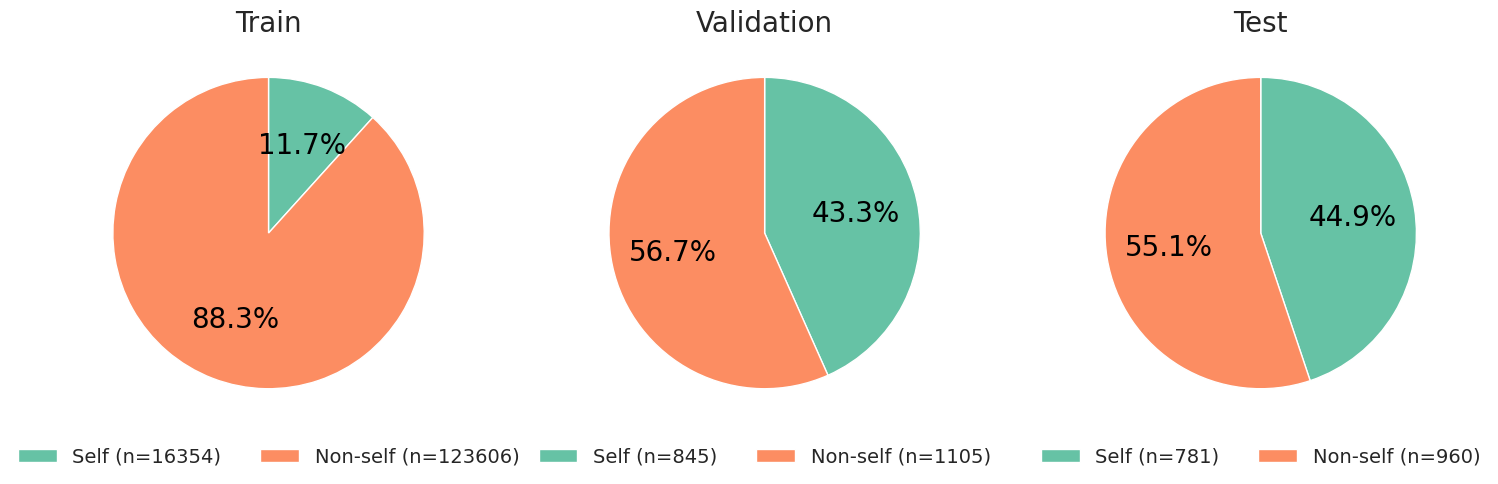

In [4]:
# 3 pie plots showing self vs non-self interactions for train/val/test
sns.set_theme(style="white")  # use seaborn styling

palette = sns.color_palette("Set2", 2)

def plot_pie(ax, counts, title):
    labels = [f"Self (n={counts[0]})", f"Non-self (n={counts[1]})"]
    wedges, _, autotexts = ax.pie(
        counts,
        colors=palette,
        startangle=90,
        autopct="%1.1f%%",
        counterclock=False,
        wedgeprops={"linewidth": 1, "edgecolor": "white"},
        textprops={"color": "black", "fontsize": 20},
    )
    ax.set_title(title, fontsize=20)
    ax.axis("equal")
    ax.legend(
        wedges,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=2,
        frameon=False,
        fontsize=14,
    )

train_counts = [len(train_self_int), len(train_non_self)]
val_counts = [len(val_self_int), len(val_non_self)]
test_counts = [len(test_self_int), len(test_non_self)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_pie(axes[0], train_counts, "Train")
plot_pie(axes[1], val_counts, "Validation")
plot_pie(axes[2], test_counts, "Test")

plt.tight_layout()
plt.show()

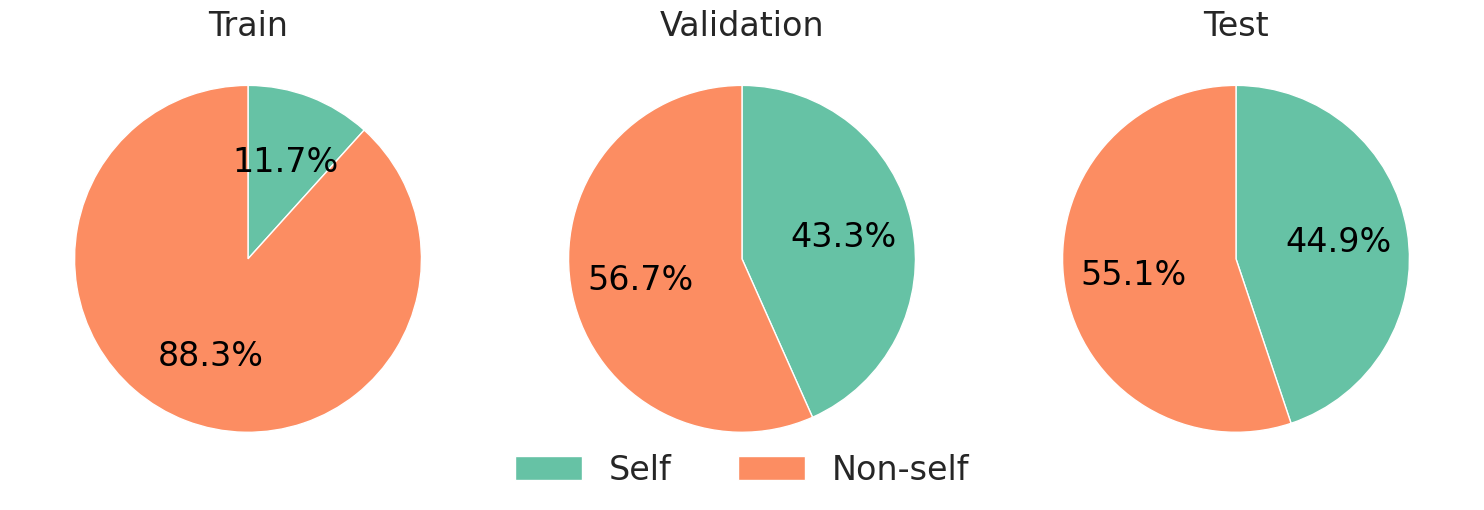

In [5]:
from matplotlib.patches import Patch

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
counts_per_split = [train_counts, val_counts, test_counts]
titles = ["Train", "Validation", "Test"]

for ax, counts, title in zip(axes2, counts_per_split, titles):
    ax.pie(
        counts,
        colors=palette,
        startangle=90,
        autopct="%1.1f%%",
        counterclock=False,
        wedgeprops={"linewidth": 1, "edgecolor": "white"},
        textprops={"color": "black", "fontsize": 24},
    )
    ax.set_title(title, fontsize=24)
    ax.axis("equal")

legend_handles = [
    Patch(facecolor=palette[0], edgecolor="white", label="Self"),
    Patch(facecolor=palette[1], edgecolor="white", label="Non-self"),
]

fig2.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=24,
    bbox_to_anchor=(0.5, -0.05),
)

plt.tight_layout()
plt.show()

# After balancing

In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
after_path = "/nfs/scratch/pinder/negative_dataset/my_repository/datasets/no_duplicates/deleak_cdhit/fully_balanced"
after_train_csv = os.path.join(after_path, "train.csv")
after_val_csv = os.path.join(after_path, "val.csv")
after_test_csv = os.path.join(after_path, "test.csv")

after_train = pd.read_csv(after_train_csv)
after_val = pd.read_csv(after_val_csv)
after_test = pd.read_csv(after_test_csv)

print(f"Train size: {len(after_train)}")

after_train = after_train[after_train["label"] == 1]
after_val = after_val[after_val["label"] == 1]
after_test = after_test[after_test["label"] == 1]

print(f"Positive Train size: {len(after_train)}")

Train size: 233988
Positive Train size: 116994


In [8]:
after_train_self_int = after_train[after_train["receptor_seq"] == after_train["ligand_seq"]]
after_val_self_int = after_val[after_val["receptor_seq"] == after_val["ligand_seq"]]
after_test_self_int = after_test[after_test["receptor_seq"] == after_test["ligand_seq"]]

print(f"Self-interacting Train size: {len(after_train_self_int)}")
print(f"Self-interacting Val size: {len(after_val_self_int)}")
print(f"Self-interacting Test size: {len(after_test_self_int)}")

after_train_non_self = after_train[after_train["receptor_seq"] != after_train["ligand_seq"]]
after_val_non_self = after_val[after_val["receptor_seq"] != after_val["ligand_seq"]]
after_test_non_self = after_test[after_test["receptor_seq"] != after_test["ligand_seq"]]

print(f"Non-self-interacting Train size: {len(after_train_non_self)}")
print(f"Non-self-interacting Val size: {len(after_val_non_self)}")
print(f"Non-self-interacting Test size: {len(after_test_non_self)}")

print(f"Check train sizes: {len(after_train_self_int) + len(after_train_non_self) == len(after_train)}")
print(f"Check val sizes: {len(after_val_self_int) + len(after_val_non_self) == len(after_val)}")
print(f"Check test sizes: {len(after_test_self_int) + len(after_test_non_self) == len(after_test)}")

Self-interacting Train size: 15531
Self-interacting Val size: 286
Self-interacting Test size: 195
Non-self-interacting Train size: 101463
Non-self-interacting Val size: 549
Non-self-interacting Test size: 381
Check train sizes: True
Check val sizes: True
Check test sizes: True


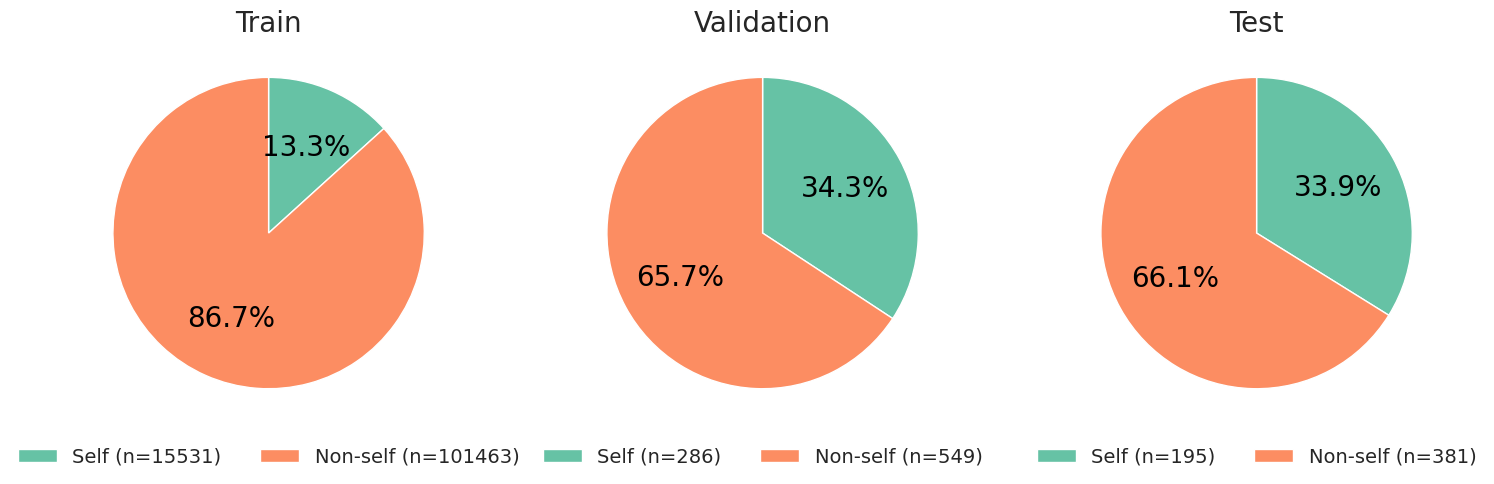

In [9]:
# 3 pie plots showing self vs non-self interactions for train/val/test
sns.set_theme(style="white")  # use seaborn styling

palette = sns.color_palette("Set2", 2)

def plot_pie(ax, counts, title):
    labels = [f"Self (n={counts[0]})", f"Non-self (n={counts[1]})"]
    wedges, _, autotexts = ax.pie(
        counts,
        colors=palette,
        startangle=90,
        autopct="%1.1f%%",
        counterclock=False,
        wedgeprops={"linewidth": 1, "edgecolor": "white"},
        textprops={"color": "black", "fontsize": 20},
    )
    ax.set_title(title, fontsize=20)
    ax.axis("equal")
    ax.legend(
        wedges,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=2,
        frameon=False,
        fontsize=14,
    )

after_train_counts = [len(after_train_self_int), len(after_train_non_self)]
after_val_counts = [len(after_val_self_int), len(after_val_non_self)]
after_test_counts = [len(after_test_self_int), len(after_test_non_self)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_pie(axes[0], after_train_counts, "Train")
plot_pie(axes[1], after_val_counts, "Validation")
plot_pie(axes[2], after_test_counts, "Test")

plt.tight_layout()
plt.show()

# Bar plot showing everything, nicer to show that balancing worked...

In [10]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
path_before = "/nfs/scratch/pinder/negative_dataset/my_repository/datasets/no_duplicates/deleak_cdhit"
path_after = "/nfs/scratch/pinder/negative_dataset/my_repository/datasets/no_duplicates/deleak_cdhit/fully_balanced"

train_before = pd.read_csv(os.path.join(path_before, "train.csv"))
train_after = pd.read_csv(os.path.join(path_after, "train.csv"))
val_before = pd.read_csv(os.path.join(path_before, "val.csv"))
val_after = pd.read_csv(os.path.join(path_after, "val.csv"))
test_before = pd.read_csv(os.path.join(path_before, "test.csv"))
test_after = pd.read_csv(os.path.join(path_after, "test.csv"))

def count_self_interactions(df):
    pos_self_int_count = 0
    neg_self_int_count = 0
    pos_non_self_count = 0
    neg_non_self_count = 0

    for idx, row in df.iterrows():
        rec_uni = row["entry"].split("--")[0].split("_")[-1]
        lig_uni = row["entry"].split("--")[1].split("_")[-1]

        # if rec_uni == "UNDEFINED" or lig_uni == "UNDEFINED":
        #     continue

        if rec_uni == lig_uni:
            if row["label"] == 1:
                pos_self_int_count += 1
            else:
                neg_self_int_count += 1
        else:
            if row["label"] == 1:
                pos_non_self_count += 1
            else:
                neg_non_self_count += 1

    return pos_self_int_count, neg_self_int_count, pos_non_self_count, neg_non_self_count

train_before_counts = count_self_interactions(train_before)
train_after_counts = count_self_interactions(train_after)
val_before_counts = count_self_interactions(val_before)
val_after_counts = count_self_interactions(val_after)
test_before_counts = count_self_interactions(test_before)
test_after_counts = count_self_interactions(test_after)

print("Train before balancing (Pos_self, Neg_self, Pos_non-self, Neg_non-self):", train_before_counts)
print("Train after balancing (Pos_self, Neg_self, Pos_non-self, Neg_non-self):", train_after_counts)
print("Validation before balancing (Pos_self, Neg_self, Pos_non-self, Neg_non-self):", val_before_counts)
print("Validation after balancing (Pos_self, Neg_self, Pos_non-self, Neg_non-self):", val_after_counts)
print("Test before balancing (Pos_self, Neg_self, Pos_non-self, Neg_non-self):", test_before_counts)
print("Test after balancing (Pos_self, Neg_self, Pos_non-self, Neg_non-self):", test_after_counts)


Train before balancing (Pos_self, Neg_self, Pos_non-self, Neg_non-self): (52057, 2013, 87903, 137947)
Train after balancing (Pos_self, Neg_self, Pos_non-self, Neg_non-self): (41765, 41783, 75229, 75211)
Validation before balancing (Pos_self, Neg_self, Pos_non-self, Neg_non-self): (1662, 0, 288, 1950)
Validation after balancing (Pos_self, Neg_self, Pos_non-self, Neg_non-self): (556, 556, 279, 279)
Test before balancing (Pos_self, Neg_self, Pos_non-self, Neg_non-self): (1539, 4, 202, 1737)
Test after balancing (Pos_self, Neg_self, Pos_non-self, Neg_non-self): (384, 384, 192, 192)


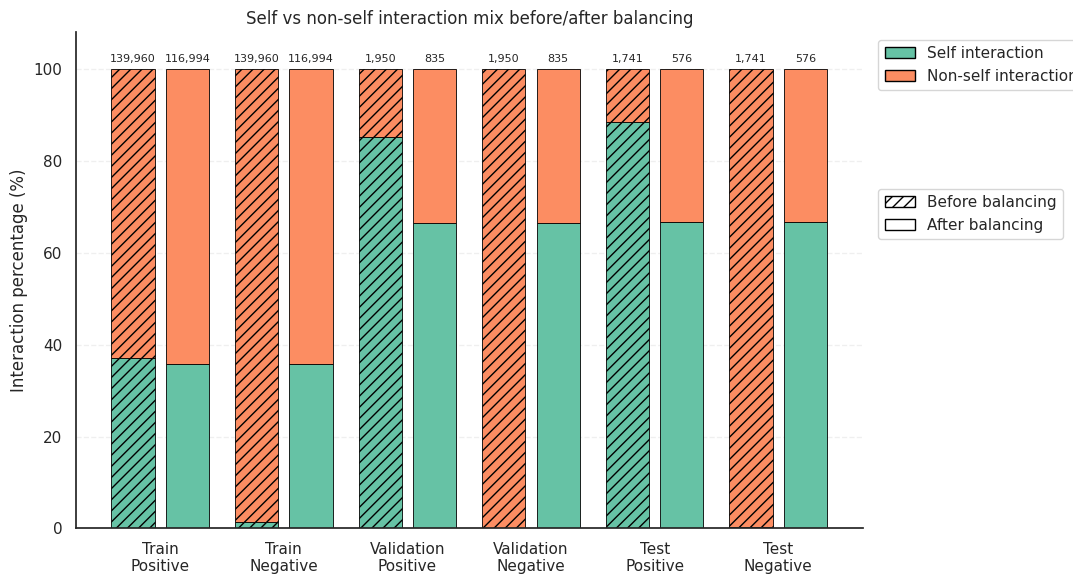

In [12]:
phase_counts = {
    "Train": {"Before": train_before_counts, "After": train_after_counts},
    "Validation": {"Before": val_before_counts, "After": val_after_counts},
    "Test": {"Before": test_before_counts, "After": test_after_counts},
}

titles = ["Train", "Validation", "Test"]

split_order = [split for split in titles if split in phase_counts]
label_order = ["Positive", "Negative"]
phase_order = ["Before", "After"]

records = []
for split in split_order:
    for phase in phase_order:
        pos_self, neg_self, pos_non, neg_non = phase_counts[split][phase]
        label_counts = {
            "Positive": (pos_self, pos_non),
            "Negative": (neg_self, neg_non),
        }
        for label in label_order:
            self_count, non_self_count = label_counts[label]
            total = self_count + non_self_count
            self_pct = (self_count / total * 100) if total else 0.0
            non_self_pct = (non_self_count / total * 100) if total else 0.0
            records.append(
                {
                    "split": split,
                    "phase": phase,
                    "label": label,
                    "self_pct": self_pct,
                    "non_self_pct": non_self_pct,
                    "self_count": self_count,
                    "non_self_count": non_self_count,
                }
            )

plot_df = pd.DataFrame(records).set_index(["split", "label", "phase"])

self_color, non_self_color = palette
fig, ax = plt.subplots(figsize=(14, 6))

bar_width = 0.35
phase_offsets = {"Before": -0.22, "After": 0.22}
group_spacing = 1.0
group_centers, group_labels = [], []
group_idx = 0

for split in split_order:
    for label in label_order:
        center = group_idx * group_spacing
        group_centers.append(center)
        group_labels.append(f"{split}\n{label}")
        for phase in phase_order:
            row = plot_df.loc[(split, label, phase)]
            x = center + phase_offsets[phase]
            hatch = "///" if phase == "Before" else ""
            ax.bar(
                x,
                row["self_pct"],
                width=bar_width,
                color=self_color,
                edgecolor="black",
                linewidth=0.6,
                hatch=hatch,
            )
            ax.bar(
                x,
                row["non_self_pct"],
                width=bar_width,
                bottom=row["self_pct"],
                color=non_self_color,
                edgecolor="black",
                linewidth=0.6,
                hatch=hatch,
            )
            ax.text(
                x,
                101,
                f"{int(row['self_count'] + row['non_self_count']):,}",
                ha="center",
                va="bottom",
                fontsize=8,
            )
        group_idx += 1

ax.set_xticks(group_centers)
ax.set_xticklabels(group_labels)
ax.set_ylim(0, 108)
ax.set_ylabel("Interaction percentage (%)")
ax.set_title("Self vs non-self interaction mix before/after balancing")
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

interaction_handles = [
    Patch(facecolor=self_color, edgecolor="black", label="Self interaction"),
    Patch(facecolor=non_self_color, edgecolor="black", label="Non-self interaction"),
]
phase_handles = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Before balancing"),
    Patch(facecolor="white", edgecolor="black", hatch="", label="After balancing"),
]

legend1 = ax.legend(handles=interaction_handles, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.legend(handles=phase_handles, loc="upper left", bbox_to_anchor=(1.01, 0.7))
ax.add_artist(legend1)

plt.tight_layout(rect=[0, 0, 0.78, 1])
# plt.show()

plt.savefig("/nfs/scratch/pinder/negative_dataset/my_repository/plots/self_int_balan_bar_plot.png")

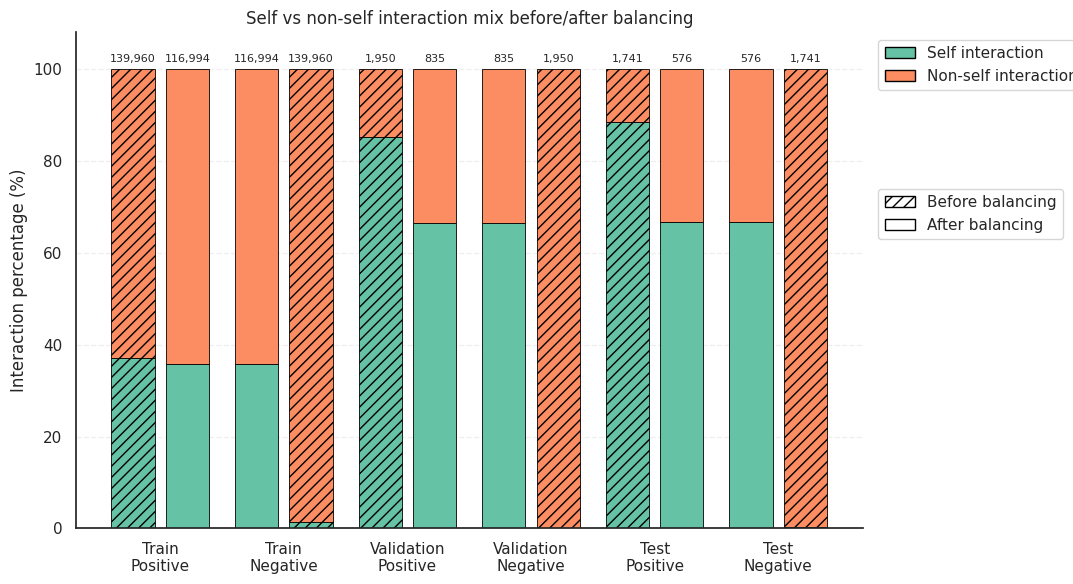

In [13]:
phase_counts = {
    "Train": {"Before": train_before_counts, "After": train_after_counts},
    "Validation": {"Before": val_before_counts, "After": val_after_counts},
    "Test": {"Before": test_before_counts, "After": test_after_counts},
}

titles = ["Train", "Validation", "Test"]

split_order = [split for split in titles if split in phase_counts]
label_order = ["Positive", "Negative"]
phase_order = ["Before", "After"]

records = []
for split in split_order:
    for phase in phase_order:
        pos_self, neg_self, pos_non, neg_non = phase_counts[split][phase]
        label_counts = {
            "Positive": (pos_self, pos_non),
            "Negative": (neg_self, neg_non),
        }
        for label in label_order:
            self_count, non_self_count = label_counts[label]
            total = self_count + non_self_count
            self_pct = (self_count / total * 100) if total else 0.0
            non_self_pct = (non_self_count / total * 100) if total else 0.0
            records.append(
                {
                    "split": split,
                    "phase": phase,
                    "label": label,
                    "self_pct": self_pct,
                    "non_self_pct": non_self_pct,
                    "self_count": self_count,
                    "non_self_count": non_self_count,
                }
            )

plot_df = pd.DataFrame(records).set_index(["split", "label", "phase"])

self_color, non_self_color = palette
fig, ax = plt.subplots(figsize=(14, 6))

bar_width = 0.35
phase_offsets = {"Before": -0.22, "After": 0.22}
group_spacing = 1.0
group_centers, group_labels = [], []
group_idx = 0

for split in split_order:
    for label in label_order:

        if label == "Negative":
            phase_offsets_local = {"Before": 0.22, "After": -0.22}
        else:
            phase_offsets_local = phase_offsets

        center = group_idx * group_spacing
        group_centers.append(center)
        group_labels.append(f"{split}\n{label}")

        for phase in phase_order:
            row = plot_df.loc[(split, label, phase)]
            x = center + phase_offsets_local[phase]
            hatch = "///" if phase == "Before" else ""
            ax.bar(
                x,
                row["self_pct"],
                width=bar_width,
                color=self_color,
                edgecolor="black",
                linewidth=0.6,
                hatch=hatch,
            )
            ax.bar(
                x,
                row["non_self_pct"],
                width=bar_width,
                bottom=row["self_pct"],
                color=non_self_color,
                edgecolor="black",
                linewidth=0.6,
                hatch=hatch,
            )
            ax.text(
                x,
                101,
                f"{int(row['self_count'] + row['non_self_count']):,}",
                ha="center",
                va="bottom",
                fontsize=8,
            )
        group_idx += 1

ax.set_xticks(group_centers)
ax.set_xticklabels(group_labels)
ax.set_ylim(0, 108)
ax.set_ylabel("Interaction percentage (%)")
ax.set_title("Self vs non-self interaction mix before/after balancing")
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

interaction_handles = [
    Patch(facecolor=self_color, edgecolor="black", label="Self interaction"),
    Patch(facecolor=non_self_color, edgecolor="black", label="Non-self interaction"),
]
phase_handles = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Before balancing"),
    Patch(facecolor="white", edgecolor="black", hatch="", label="After balancing"),
]

legend1 = ax.legend(handles=interaction_handles, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.legend(handles=phase_handles, loc="upper left", bbox_to_anchor=(1.01, 0.7))
ax.add_artist(legend1)

plt.tight_layout(rect=[0, 0, 0.78, 1])
# plt.show()

plt.savefig("/nfs/scratch/pinder/negative_dataset/my_repository/plots/self_int_balan_bar_plot.png")

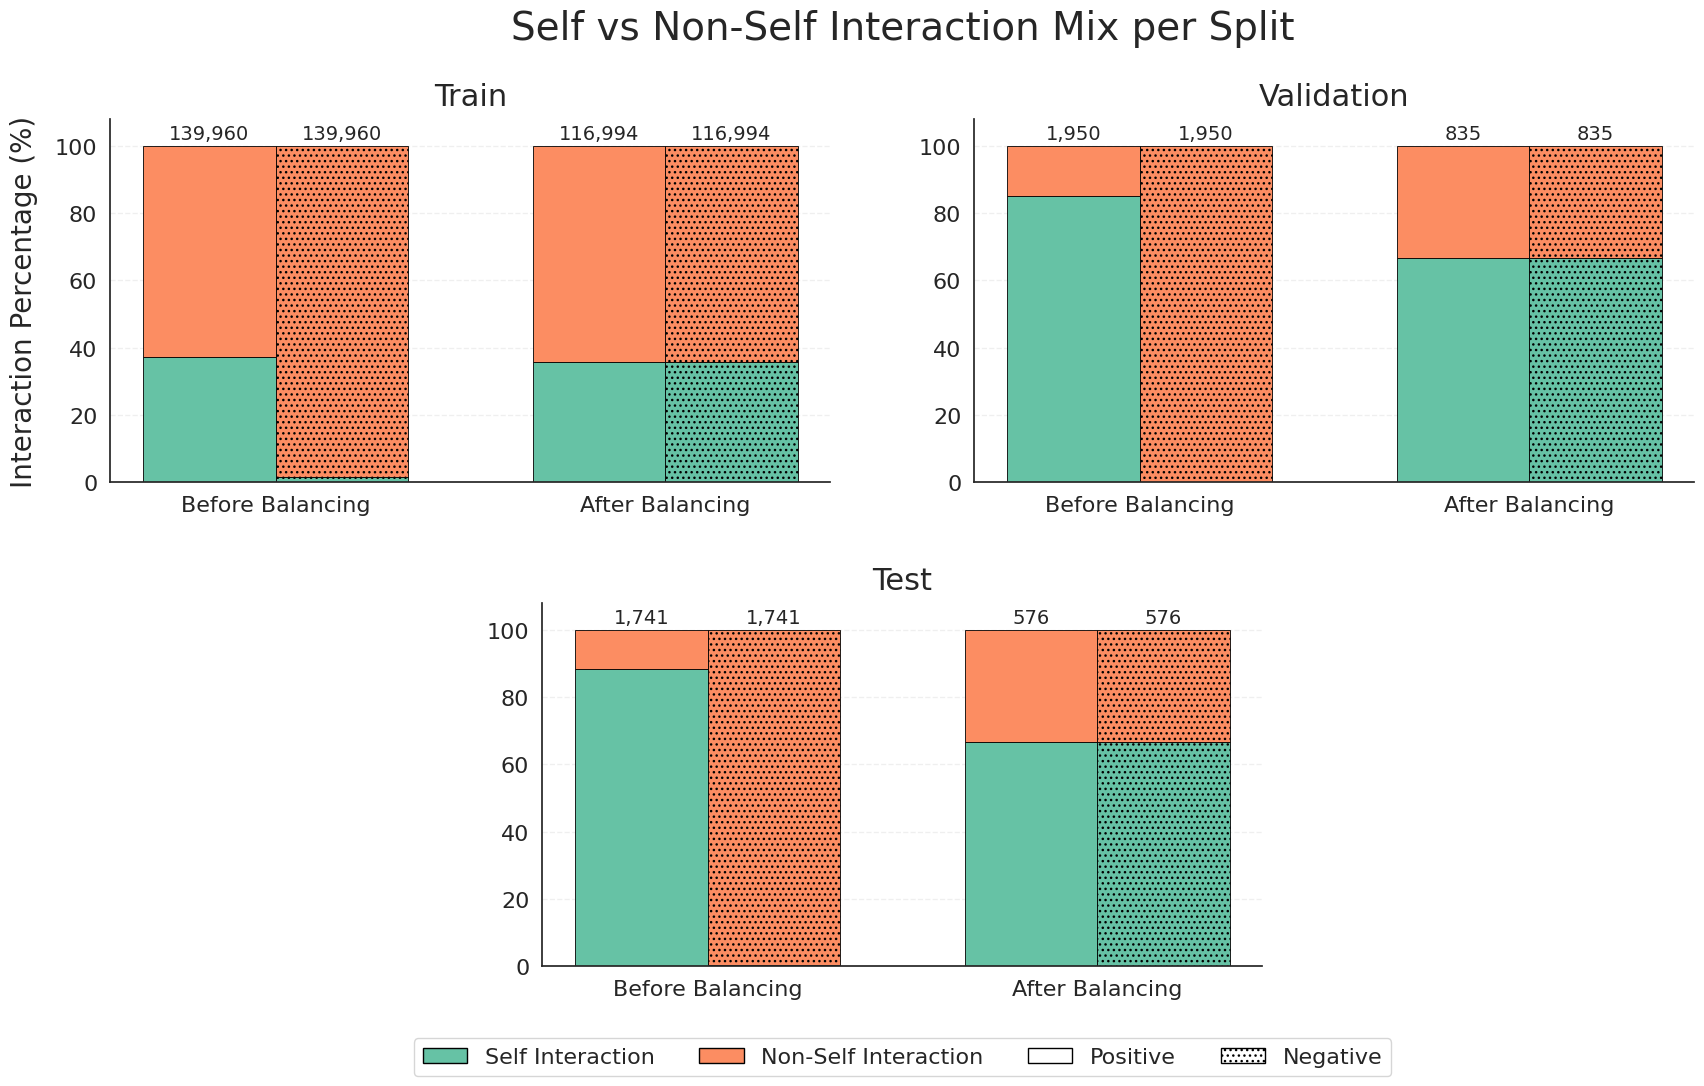

In [14]:
from matplotlib.patches import Patch

phase_counts = {
    "Train": {"Before": train_before_counts, "After": train_after_counts},
    "Validation": {"Before": val_before_counts, "After": val_after_counts},
    "Test": {"Before": test_before_counts, "After": test_after_counts},
}

split_order = [split for split in ["Train", "Validation", "Test"] if split in phase_counts]
phase_order = ["Before", "After"]
label_order = ["Positive", "Negative"]

self_color, non_self_color = palette
fig = plt.figure(figsize=(18, 11))

FONT_SUPTITLE = 28
FONT_SUBPLOT = 22
FONT_AXIS = 20
FONT_TICK = 16
FONT_ANNOT = 14
FONT_LEGEND = 16

# Fixed positions guarantee equal panel sizes for all three splits.
panel_w = 0.40
panel_h = 0.33
y_top = 0.56
y_bottom = 0.12
x_left = 0.06
x_right = 0.54
x_center = (1 - panel_w) / 2

axes_by_split = {}
first_ax = None
for split in split_order:
    if split == "Train":
        pos = [x_left, y_top, panel_w, panel_h]
    elif split == "Validation":
        pos = [x_right, y_top, panel_w, panel_h]
    elif split == "Test":
        pos = [x_center, y_bottom, panel_w, panel_h]
    else:
        continue

    if first_ax is None:
        ax = fig.add_axes(pos)
        first_ax = ax
    else:
        ax = fig.add_axes(pos, sharey=first_ax)
    axes_by_split[split] = ax

x_positions = [0, 1]
x_labels = ["Before Balancing", "After Balancing"]
bar_width = 0.34
label_offsets = {"Positive": -bar_width / 2, "Negative": bar_width / 2}
label_hatches = {"Positive": "", "Negative": "..."}

for split in split_order:
    ax = axes_by_split[split]
    for label in label_order:
        self_pcts = []
        non_self_pcts = []
        totals = []

        for phase in phase_order:
            pos_self, neg_self, pos_non, neg_non = phase_counts[split][phase]
            if label == "Positive":
                self_count, non_self_count = pos_self, pos_non
            else:
                self_count, non_self_count = neg_self, neg_non

            total = self_count + non_self_count
            self_pct = (self_count / total * 100) if total else 0.0
            non_self_pct = (non_self_count / total * 100) if total else 0.0
            self_pcts.append(self_pct)
            non_self_pcts.append(non_self_pct)
            totals.append(total)

        xs = [x + label_offsets[label] for x in x_positions]
        hatch = label_hatches[label]
        ax.bar(
            xs,
            self_pcts,
            width=bar_width,
            color=self_color,
            edgecolor="black",
            linewidth=0.6,
            hatch=hatch,
        )
        ax.bar(
            xs,
            non_self_pcts,
            width=bar_width,
            bottom=self_pcts,
            color=non_self_color,
            edgecolor="black",
            linewidth=0.6,
            hatch=hatch,
        )

        for x, total in zip(xs, totals):
            ax.text(x, 101, f"{int(total):,}", ha="center", va="bottom", fontsize=FONT_ANNOT)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=FONT_TICK)
    ax.set_ylim(0, 108)
    ax.set_title(split, fontsize=FONT_SUBPLOT, pad=10)
    ax.tick_params(axis="y", labelsize=FONT_TICK)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

first_ax.set_ylabel("Interaction Percentage (%)", fontsize=FONT_AXIS, labelpad=12)
fig.suptitle("Self vs Non-Self Interaction Mix per Split", y=0.99, fontsize=FONT_SUPTITLE)

interaction_handles = [
    Patch(facecolor=self_color, edgecolor="black", label="Self Interaction"),
    Patch(facecolor=non_self_color, edgecolor="black", label="Non-Self Interaction"),
]
label_handles = [
    Patch(facecolor="white", edgecolor="black", hatch="", label="Positive"),
    Patch(facecolor="white", edgecolor="black", hatch="...", label="Negative"),
]

fig.legend(
    handles=interaction_handles + label_handles,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.01),
    fontsize=FONT_LEGEND,
)

# plt.show()
plt.savefig("/nfs/scratch/pinder/negative_dataset/my_repository/plots/self_int_balan_bar_plot_split.png")


In [15]:
# check pos train int
train_pos_int = train_after[train_after["label"] == 1]

count = 0
for idx, row in train_pos_int.iterrows():
    rec_uni = row["entry"].split("--")[0].split("_")[-1]
    lig_uni = row["entry"].split("--")[1].split("_")[-1]

    if rec_uni == lig_uni:
        count += 1

count

41765

In [16]:
# percentages before self int balancing

phase_counts = {
    "Train": {"Before": train_before_counts, "After": train_after_counts},
    "Validation": {"Before": val_before_counts, "After": val_after_counts},
    "Test": {"Before": test_before_counts, "After": test_after_counts},
}

split_order = [split for split in titles if split in phase_counts]
label_order = ["Positive", "Negative"]
phase_order = ["Before", "After"]

records = []
for split in split_order:
    for phase in phase_order:
        pos_self, neg_self, pos_non, neg_non = phase_counts[split][phase]

def count_percentages(counts):
    pos_self, neg_self, pos_non, neg_non = counts
    total_pos = pos_self + pos_non
    total_neg = neg_self + neg_non
    pos_self_pct = (pos_self / total_pos * 100) if total_pos else 0.0
    pos_non_pct = (pos_non / total_pos * 100) if total_pos else 0.0
    neg_self_pct = (neg_self / total_neg * 100) if total_neg else 0.0
    neg_non_pct = (neg_non / total_neg * 100) if total_neg else 0.0
    print(f"Positive interactions: Self {pos_self_pct:.2f}%, Non-self {pos_non_pct:.2f}%")
    print(f"Negative interactions: Self {neg_self_pct:.2f}%, Non-self {neg_non_pct:.2f}%")
    return {
        "Positive": (pos_self_pct, pos_non_pct),
        "Negative": (neg_self_pct, neg_non_pct),
    }

count_percentages(train_before_counts)
count_percentages(val_before_counts)
count_percentages(test_before_counts)



Positive interactions: Self 37.19%, Non-self 62.81%
Negative interactions: Self 1.44%, Non-self 98.56%
Positive interactions: Self 85.23%, Non-self 14.77%
Negative interactions: Self 0.00%, Non-self 100.00%
Positive interactions: Self 88.40%, Non-self 11.60%
Negative interactions: Self 0.23%, Non-self 99.77%


{'Positive': (88.39747271682941, 11.602527283170591),
 'Negative': (0.22975301550832855, 99.77024698449168)}

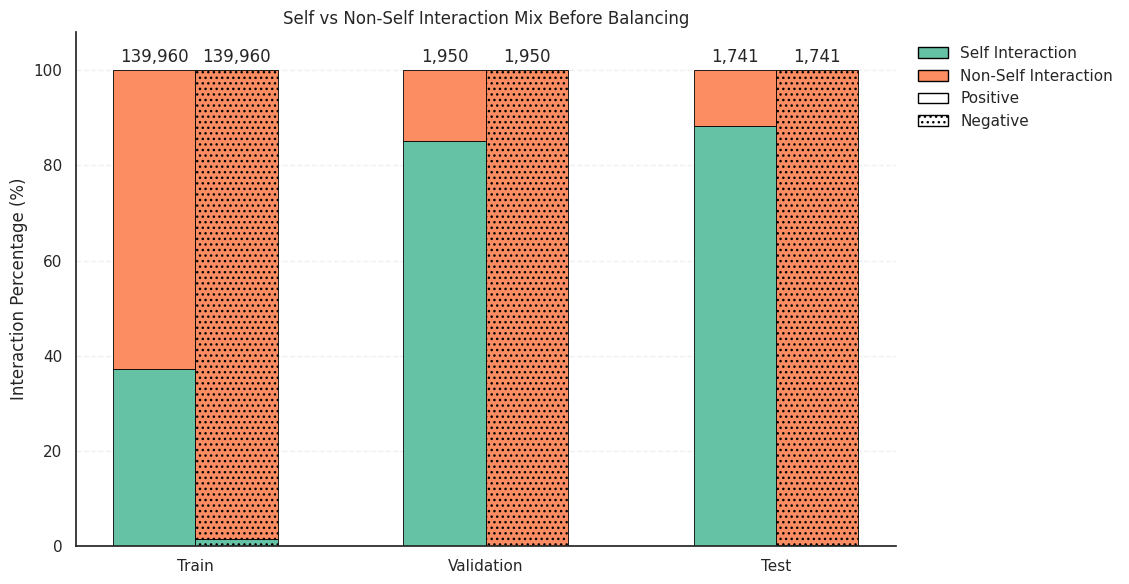

In [17]:
counts_before = {
    "Train": train_before_counts,
    "Validation": val_before_counts,
    "Test": test_before_counts,
}

split_order = ["Train", "Validation", "Test"]
label_order = ["Positive", "Negative"]
label_hatches = {"Positive": "", "Negative": "..."}
self_color, non_self_color = palette

fig, ax = plt.subplots(figsize=(14, 6))

bar_width = 0.34
group_spacing = 1.2
group_centers = []
group_labels = []

for i, split in enumerate(split_order):
    pos_self, neg_self, pos_non, neg_non = counts_before[split]
    split_counts = {
        "Positive": (pos_self, pos_non),
        "Negative": (neg_self, neg_non),
    }

    center = i * group_spacing
    group_centers.append(center)
    group_labels.append(split)

    xs = [center - bar_width / 2, center + bar_width / 2]

    for x, label in zip(xs, label_order):
        self_count, non_self_count = split_counts[label]
        total = self_count + non_self_count
        self_pct = (self_count / total * 100) if total else 0.0
        non_self_pct = (non_self_count / total * 100) if total else 0.0

        ax.bar(
            x,
            self_pct,
            width=bar_width,
            color=self_color,
            edgecolor="black",
            linewidth=0.6,
            hatch=label_hatches[label],
        )
        ax.bar(
            x,
            non_self_pct,
            width=bar_width,
            bottom=self_pct,
            color=non_self_color,
            edgecolor="black",
            linewidth=0.6,
            hatch=label_hatches[label],
        )

        ax.text(x, 101, f"{total:,}", ha="center", va="bottom", fontsize=12)

ax.set_xticks(group_centers)
ax.set_xticklabels(group_labels)
ax.set_ylim(0, 108)
ax.set_ylabel("Interaction Percentage (%)")
ax.set_title("Self vs Non-Self Interaction Mix Before Balancing")
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

interaction_handles = [
    Patch(facecolor=self_color, edgecolor="black", label="Self Interaction"),
    Patch(facecolor=non_self_color, edgecolor="black", label="Non-Self Interaction"),
]
label_handles = [
    Patch(facecolor="white", edgecolor="black", hatch="", label="Positive"),
    Patch(facecolor="white", edgecolor="black", hatch="...", label="Negative"),
]

ax.legend(
    handles=interaction_handles + label_handles,
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

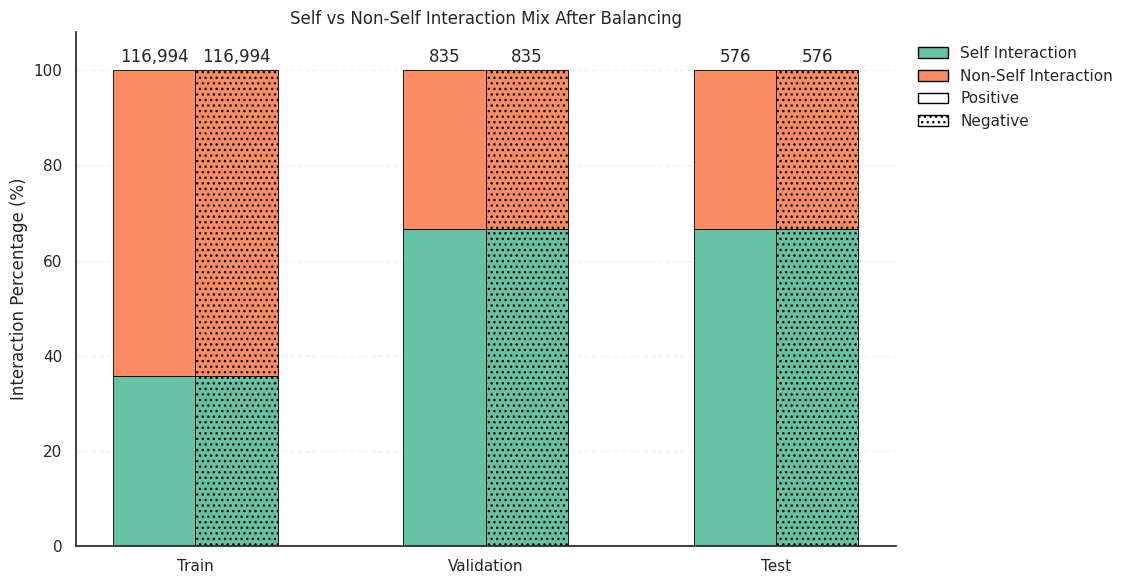

In [18]:
# Same style as the "before balancing" plot, but using AFTER balancing counts

counts_after = {
    "Train": train_after_counts,
    "Validation": val_after_counts,
    "Test": test_after_counts,
}

split_order = ["Train", "Validation", "Test"]
label_order = ["Positive", "Negative"]
label_hatches = {"Positive": "", "Negative": "..."}
self_color, non_self_color = palette

fig, ax = plt.subplots(figsize=(14, 6))

bar_width = 0.34
group_spacing = 1.2
group_centers = []
group_labels = []

for i, split in enumerate(split_order):
    pos_self, neg_self, pos_non, neg_non = counts_after[split]
    split_counts = {
        "Positive": (pos_self, pos_non),
        "Negative": (neg_self, neg_non),
    }

    center = i * group_spacing
    group_centers.append(center)
    group_labels.append(split)
    xs = [center - bar_width / 2, center + bar_width / 2]

    for x, label in zip(xs, label_order):
        self_count, non_self_count = split_counts[label]
        total = self_count + non_self_count
        self_pct = (self_count / total * 100) if total else 0.0
        non_self_pct = (non_self_count / total * 100) if total else 0.0

        ax.bar(
            x, self_pct,
            width=bar_width,
            color=self_color,
            edgecolor="black",
            linewidth=0.6,
            hatch=label_hatches[label],
        )
        ax.bar(
            x, non_self_pct,
            width=bar_width,
            bottom=self_pct,
            color=non_self_color,
            edgecolor="black",
            linewidth=0.6,
            hatch=label_hatches[label],
        )

        ax.text(x, 101, f"{total:,}", ha="center", va="bottom", fontsize=12)

ax.set_xticks(group_centers)
ax.set_xticklabels(group_labels)
ax.set_ylim(0, 108)
ax.set_ylabel("Interaction Percentage (%)")
ax.set_title("Self vs Non-Self Interaction Mix After Balancing")
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

interaction_handles = [
    Patch(facecolor=self_color, edgecolor="black", label="Self Interaction"),
    Patch(facecolor=non_self_color, edgecolor="black", label="Non-Self Interaction"),
]
label_handles = [
    Patch(facecolor="white", edgecolor="black", hatch="", label="Positive"),
    Patch(facecolor="white", edgecolor="black", hatch="...", label="Negative"),
]

ax.legend(
    handles=interaction_handles + label_handles,
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()